In [1]:
import h5py
import numpy as np
import os
import matplotlib.pyplot as plt

from PIL import Image
import math
import torch
import torch.nn as nn
import torch.optim as optim
from thop import profile
from einops import rearrange 
from einops.layers.torch import Rearrange, Reduce
from timm.models.layers import trunc_normal_, DropPath
import sys
module_dir_scu = "/global/u2/k/kberard/SCGSR/Research/Diamond/stock_models/SCUNet" 
sys.path.insert(0, module_dir_scu)
from models.network_scunet import SCUNet as SCUNet
from torch.utils.data import Dataset
from utils import utils_image as util
import joblib
from sklearn.preprocessing import MinMaxScaler

/global/u2/k/kberard/environments/SCGSR/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/global/u2/k/kberard/environments/SCGSR/lib/python3.12/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [2]:

with h5py.File('/global/u2/k/kberard/SCGSR/Research/Diamond/Data/density_tot_ref.h5', 'r') as file:
    ref_d = file['density'][:]

In [3]:
#### test file #######
with h5py.File('/pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0000652279.h5', 'r') as file:
    #print("Keys: %s" % file.keys())
    test_d = file['density'][:]

In [4]:
def D_JS(p1,p2,tol=1e-16):
    p1= p1/np.sum(p1)
    p2=p2/np.sum(p2)
    pm = (p1+p2)/2
    p1_nonzero = np.abs(p1)>tol
    p2_nonzero = np.abs(p2)>tol
    p1  = np.abs(p1[p1_nonzero])
    pm1 = np.abs(pm[p1_nonzero])
    p2  = np.abs(p2[p2_nonzero])
    pm2 = np.abs(pm[p2_nonzero])
    d = .5*( (p1*np.log(p1/pm1)).sum() + (p2*np.log(p2/pm2)).sum() )
    d /= np.log(2) # normalize to max of 1
    return d

In [5]:
def encode_voxel_to_rgb(test_d, save_path='slice_scalers.npz'):
    """
    Normalize each XY slice independently and encode to RGB (repeated channels).
    Saves (min, max) for each slice for reconstruction.
    
    Returns:
        rgb_volume: (64, 64, 64, 3)
    """
    rgb_volume = np.zeros((64, 64, 64, 3), dtype=np.float32)
    mins = []
    maxs = []

    for i in range(64):
        slice_2d = test_d[i, :, :]
        s_min = float(slice_2d.min())
        s_max = float(slice_2d.max())

        if s_max == s_min:
            s_max = s_min + 1e-6  # Avoid divide-by-zero for flat slices

        normed = (slice_2d - s_min) / (s_max - s_min)
        rgb_volume[i, :, :, :] = np.stack([normed]*3, axis=-1)  # (64, 64, 3)

        mins.append(s_min)
        maxs.append(s_max)

    np.savez(save_path, mins=np.array(mins), maxs=np.array(maxs))
    return rgb_volume  # shape: (64, 64, 64, 3)


In [6]:
def decode_rgb_to_voxel(rgb_volume, save_path='slice_scalers.npz'):
    """
    Decode per-slice normalized RGB volume back into scalar 3D volume.
    Assumes all RGB channels are identical.
    
    Args:
        rgb_volume: shape (64, 64, 64, 3)
    """
    data = np.load(save_path)
    mins = data['mins']
    maxs = data['maxs']

    test_d = np.zeros((64, 64, 64), dtype=np.float32)

    for i in range(64):
        rgb_slice = rgb_volume[i]  # (64, 64, 3)
        gray = rgb_slice[:, :, 0]
        restored = gray * (maxs[i] - mins[i]) + mins[i]
        test_d[i] = restored

    return test_d


In [7]:
print("enc dec loaded")

enc dec loaded


In [8]:
############### scunet_Pretrained ###############

def scunet_pre_test_pipeline(test_d, ref_d):
    # Encode
    test_rgb = encode_voxel_to_rgb(test_d)
    ref_rgb  = encode_voxel_to_rgb(ref_d)

    # Denoise each of 64 RGB slices
    denoised_rgb = np.zeros_like(test_rgb)
    # Load pretrained model
    model = SCUNet(in_nc=3, config=[4, 4, 4, 4, 4, 4, 4], dim=64)
    model_path = '/global/u2/k/kberard/SCGSR/Research/Diamond/stock_models/SCUNet/model_zoo/scunet_color_25.pth'  # Adjust if needed
    model.load_state_dict(torch.load(model_path, map_location='cpu'), strict=True)
    model.eval()
    model.to('cuda' if torch.cuda.is_available() else 'cpu')

    def denoise_with_scunet(rgb_image_np, model, device='cuda'):
        """
        Args:
            rgb_image_np: (H, W, 3), float32 or float64, values in [0,1]
            model: SCUNet model
            device: 'cuda' or 'cpu'
        
        Returns:
            Denoised image (H, W, 3), uint8
        """
        # Make sure image is float32 in [0,1]
        img = rgb_image_np.astype(np.float32)
        img_tensor = util.single2tensor4(img).to(device)
        with torch.no_grad():
            output_tensor = model(img_tensor)
        output_np = util.tensor2single(output_tensor)
        return np.clip(output_np.transpose(1, 2, 0), 0, 1)
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    

    for i in range(test_rgb.shape[0]):
        
        noisy_slice = test_rgb[i]
        denoise =denoise_with_scunet(noisy_slice, model, device=device)
        denoised_rgb[i] = np.transpose(denoise, (0,2,1))
        

    ####

    # Reconstruct full 3D volume
    denoised_d = decode_rgb_to_voxel(denoised_rgb)

    # --- Evaluation ---
    print("\n>>> Evaluation Metrics 2D")
    jsd_noisy_2d = D_JS(test_d,
        ref_d
    )
    jsd_denoised_2d = D_JS(
        denoised_d,ref_d
    )

    norm_noisy_2d = np.linalg.norm(test_d - ref_d)
    norm_denoised_2d = np.linalg.norm(denoised_d - ref_d)

    print(f"2-norm (noisy vs ref):     {norm_noisy_2d:.4f}")
    print(f"2-norm (denoised vs ref): {norm_denoised_2d:.4f}")
    print(f"JSD   (noisy vs ref):     {jsd_noisy_2d:.6f}")
    print(f"JSD   (denoised vs ref):  {jsd_denoised_2d:.6f}")

    ##########
    # --- Evaluation ---
    print("\n>>> Evaluation Metrics 3D")
    jsd_noisy = D_JS(test_d,
        ref_d
    )
    jsd_denoised = D_JS(
        denoised_d,ref_d
    )

    norm_noisy = np.linalg.norm(test_d - ref_d)
    norm_denoised = np.linalg.norm(denoised_d - ref_d)

    print(f"2-norm (noisy vs ref):     {norm_noisy:.4f}")
    print(f"2-norm (denoised vs ref): {norm_denoised:.4f}")
    print(f"JSD   (noisy vs ref):     {jsd_noisy:.6f}")
    print(f"JSD   (denoised vs ref):  {jsd_denoised:.6f}")
    #########

    # --- Plot example slices ---
    slice_idx = 32
    plt.figure(figsize=(12, 6))
    titles = ['Noisy', 'Denoised', 'Reference']
    data = [test_d[slice_idx], denoised_d[slice_idx], ref_d[slice_idx]]
    for i in range(3):
        plt.subplot(1, 3, i+1)
        plt.imshow(data[i], cmap='viridis')
        plt.title(f"{titles[i]} (z={slice_idx})")
        plt.axis('off')
    plt.tight_layout()
    plt.show()
    return(denoised_d,jsd_denoised_2d)


In [9]:
print("scunet pretrained loaded")

scunet pretrained loaded


In [10]:
############### scunet_Trained ###############

def scunet_trained_test_pipeline(test_d, ref_d):
    # Encode
    test_rgb = encode_voxel_to_rgb(test_d)
    ref_rgb  = encode_voxel_to_rgb(ref_d)

    # Denoise each of 64 RGB slices
    denoised_rgb = np.zeros_like(test_rgb)
    
    torch.serialization.add_safe_globals([SCUNet])
    model = torch.load('/pscratch/sd/k/kberard/SCGSR/3D_VMC/Model_Train_dat/Scunet_trained_Models/'+'238800000000'+'_scunet_trained', weights_only=False, map_location=torch.device("cpu"))
    model.eval()

    def single2tensor4(img):
        """
        Convert HWC image [0,1] float32 to NCHW tensor
        """
        img_tensor = torch.from_numpy(np.transpose(img, (2, 0, 1))).float().unsqueeze(0)  # shape (1, 3, H, W)
        return img_tensor
    def tensor2single(tensor):
        """
        Convert NCHW or CHW tensor to HWC numpy array, clipped to [0,1]
        """
        tensor = tensor.squeeze().cpu().detach().numpy()
        if tensor.ndim == 3:
            img_np = np.transpose(tensor, (1, 2, 0))  # CHW -> HWC
        else:
            img_np = tensor  # in case it's grayscale
        return np.clip(img_np, 0, 1)


    def denoise_with_scunet(rgb_image_np, model, device='cpu'):
        """
        Denoise a single RGB image using SCUNet.
    
        Args:
            rgb_image_np: (H, W, 3), float32, values in [0,1]
            model: PyTorch SCUNet model
            device: 'cuda' or 'cpu'
    
        Returns:
            Denoised image (H, W, 3), float32 in [0,1]
        """
        img = rgb_image_np.astype(np.float32)
        
        # Ensure range is [0, 1]
        img = np.clip(img, 0, 1)
    
        img_tensor = single2tensor4(img).to(device)
    
        with torch.no_grad():
            output_tensor = model(img_tensor)
    
        output_np = tensor2single(output_tensor)
        return output_np

    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    


    
    for i in range(test_rgb.shape[0]):
        noisy_slice = test_rgb[i]  # shape: (H, W, 3)
    
        denoised = denoise_with_scunet(noisy_slice, model, device=device)  # shape: (H, W, 3)
    
        if np.isnan(denoised).any():
            print(f"⚠️ NaNs detected in denoised slice {i}")
    
        denoised_rgb[i] = denoised



        

    ####

    # Reconstruct full 3D volume
    denoised_d = decode_rgb_to_voxel(denoised_rgb)


    # --- Evaluation ---
    print("\n>>> Evaluation Metrics 2D")
    jsd_noisy_2d = D_JS(test_d,
       ref_d
    )
    jsd_denoised_2d = D_JS(
        denoised_d,ref_d
    )

    norm_noisy_2d = np.linalg.norm(test_d - ref_d)
    norm_denoised_2d = np.linalg.norm(denoised_d -ref_d)

    print(f"2-norm (noisy vs ref):     {norm_noisy_2d:.4f}")
    print(f"2-norm (denoised vs ref): {norm_denoised_2d:.4f}")
    print(f"JSD   (noisy vs ref):     {jsd_noisy_2d:.6f}")
    print(f"JSD   (denoised vs ref):  {jsd_denoised_2d:.6f}")

    ##########
    # --- Evaluation ---
    print("\n>>> Evaluation Metrics 3D")
    jsd_noisy = D_JS(test_d,
        ref_d
    )
    jsd_denoised = D_JS(
        denoised_d,ref_d
    )

    norm_noisy = np.linalg.norm(test_d - ref_d)
    norm_denoised = np.linalg.norm(denoised_d - ref_d)

    print(f"2-norm (noisy vs ref):     {norm_noisy:.4f}")
    print(f"2-norm (denoised vs ref): {norm_denoised:.4f}")
    print(f"JSD   (noisy vs ref):     {jsd_noisy:.6f}")
    print(f"JSD   (denoised vs ref):  {jsd_denoised:.6f}")
    #########

    # --- Plot example slices ---
    slice_idx = 32
    plt.figure(figsize=(12, 6))
    titles = ['Noisy', 'Denoised', 'Reference']
    data = [test_d[slice_idx], denoised_d[slice_idx], ref_d[slice_idx]]
    for i in range(3):
        plt.subplot(1, 3, i+1)
        plt.imshow(data[i], cmap='viridis')
        plt.title(f"{titles[i]} (z={slice_idx})")
        plt.axis('off')
    plt.tight_layout()
    plt.show()
    return(denoised_d,jsd_denoised_2d)


In [11]:
print("scunet trained loaded")

scunet trained loaded


In [12]:
############## scunet_TL ##################


def scunet_FT_test_pipeline(test_d, ref_d):
    # Set device first
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    # Encode
    test_rgb = encode_voxel_to_rgb(test_d)
    ref_rgb  = encode_voxel_to_rgb(ref_d)

    # Denoise each of 64 RGB slices
    denoised_rgb = np.zeros_like(test_rgb)

    # Optional: only needed if loading full model with class definition
    torch.serialization.add_safe_globals([SCUNet])

    # Load model AFTER setting device
    model = torch.load('/pscratch/sd/k/kberard/SCGSR/3D_VMC/Model_Train_dat/Scunet_FT_Models/'+'238800000000'+'_scunet_FT', map_location='cpu', weights_only=False)
    model.eval()

    def single2tensor4(img):
        """
        Convert HWC image [0,1] float32 to NCHW tensor
        """
        img_tensor = torch.from_numpy(np.transpose(img, (2, 0, 1))).float().unsqueeze(0)  # shape (1, 3, H, W)
        return img_tensor
    def tensor2single(tensor):
        """
        Convert NCHW or CHW tensor to HWC numpy array, clipped to [0,1]
        """
        tensor = tensor.squeeze().cpu().detach().numpy()
        if tensor.ndim == 3:
            img_np = np.transpose(tensor, (1, 2, 0))  # CHW -> HWC
        else:
            img_np = tensor  # in case it's grayscale
        return np.clip(img_np, 0, 1)


    def denoise_with_scunet(rgb_image_np, model, device='cuda'):
        """
        Denoise a single RGB image using SCUNet.
    
        Args:
            rgb_image_np: (H, W, 3), float32, values in [0,1]
            model: PyTorch SCUNet model
            device: 'cuda' or 'cpu'
    
        Returns:
            Denoised image (H, W, 3), float32 in [0,1]
        """
        img = rgb_image_np.astype(np.float32)
        
        # Ensure range is [0, 1]
        img = np.clip(img, 0, 1)
    
        img_tensor = single2tensor4(img).to(device)
    
        with torch.no_grad():
            output_tensor = model(img_tensor)
    
        output_np = tensor2single(output_tensor)
        return output_np

    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    


    
    for i in range(test_rgb.shape[0]):
        noisy_slice = test_rgb[i]  # shape: (H, W, 3)
    
        denoised = denoise_with_scunet(noisy_slice, model, device=device)  # shape: (H, W, 3)
    
        if np.isnan(denoised).any():
            print(f"⚠️ NaNs detected in denoised slice {i}")
    
        denoised_rgb[i] = denoised



        

    ####

    # Reconstruct full 3D volume
    denoised_d = decode_rgb_to_voxel(denoised_rgb)

    
    # --- Evaluation ---
    print("\n>>> Evaluation Metrics 2D")
    jsd_noisy_2d = D_JS(test_d,
        ref_d
    )
    jsd_denoised_2d = D_JS(
        denoised_d,ref_d
    )

    norm_noisy_2d = np.linalg.norm(test_d - ref_d)
    norm_denoised_2d = np.linalg.norm(denoised_d - ref_d)

    print(f"2-norm (noisy vs ref):     {norm_noisy_2d:.4f}")
    print(f"2-norm (denoised vs ref): {norm_denoised_2d:.4f}")
    print(f"JSD   (noisy vs ref):     {jsd_noisy_2d:.6f}")
    print(f"JSD   (denoised vs ref):  {jsd_denoised_2d:.6f}")

    ##########
    # --- Evaluation ---
    print("\n>>> Evaluation Metrics 3D")
    jsd_noisy = D_JS(test_d,
        ref_d
    )
    jsd_denoised = D_JS(
        denoised_d,ref_d
    )

    norm_noisy = np.linalg.norm(test_d - ref_d)
    norm_denoised = np.linalg.norm(denoised_d - ref_d)

    print(f"2-norm (noisy vs ref):     {norm_noisy:.4f}")
    print(f"2-norm (denoised vs ref): {norm_denoised:.4f}")
    print(f"JSD   (noisy vs ref):     {jsd_noisy:.6f}")
    print(f"JSD   (denoised vs ref):  {jsd_denoised:.6f}")
    #########

    # --- Plot example slices ---
    slice_idx = 32
    plt.figure(figsize=(12, 6))
    titles = ['Noisy', 'Denoised', 'Reference']
    data = [test_d[slice_idx], denoised_d[slice_idx], ref_d[slice_idx]]
    for i in range(3):
        plt.subplot(1, 3, i+1)
        plt.imshow(data[i], cmap='viridis')
        plt.title(f"{titles[i]} (z={slice_idx})")
        plt.axis('off')
    plt.tight_layout()
    plt.show()
    return(denoised_d,jsd_denoised_2d)


In [13]:
print("scunet TL loaded")

scunet TL loaded


In [14]:
def run_denoising_pipeline(noisy_path, ref_path, model_name, output_file='denoised_output.npy'):
    # convert h5 arrays 
    import h5py
    import numpy as np

    # Load data
    with h5py.File(ref_path, 'r') as file:
        ref_d = file['density'][:]
    with h5py.File(noisy_path, 'r') as file:
        test_d = file['density'][:]

    # Pick model pipeline
    if model_name == 'scunet_trained':
        denoised_density,jsd_denoised =scunet_trained_test_pipeline(test_d, ref_d)
    elif model_name == 'scunet_pre':
        denoised_density,jsd_denoised =scunet_pre_test_pipeline(test_d, ref_d)
    elif model_name == 'scunet_ft':
        denoised_density,jsd_denoised =scunet_FT_test_pipeline(test_d, ref_d)
    else:
        raise ValueError(f"Unsupported model name: {model_name}")

    # Save denoised result
    #np.save(output_file, denoised_density)
    print(f"\n Denoised matrix saved to {output_file}")
    return(denoised_density,jsd_denoised)


Found 1 noisy files.

=== Running model: scunet_trained ===

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0002
JSD   (noisy vs ref):     0.000002
JSD   (denoised vs ref):  0.000026

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0002
JSD   (noisy vs ref):     0.000002
JSD   (denoised vs ref):  0.000026


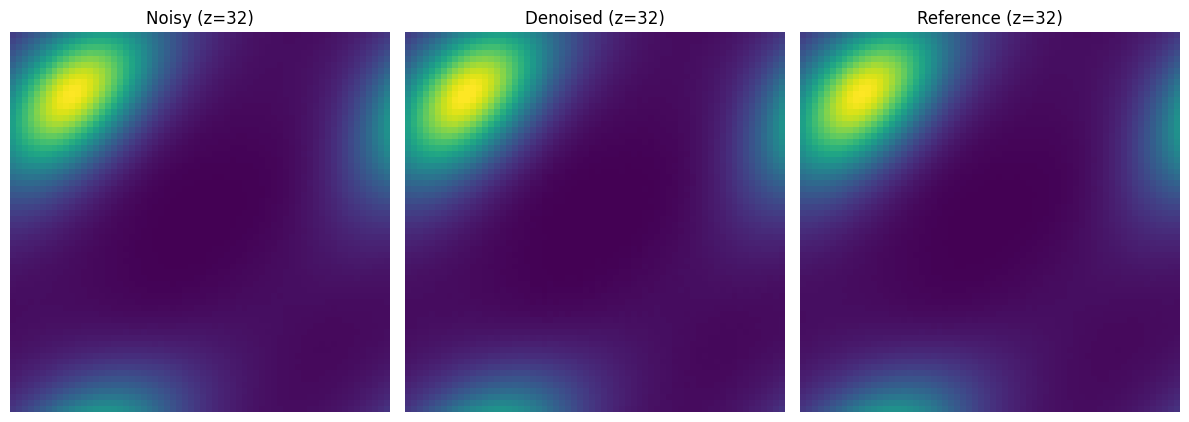


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_5283219951_scunet_trained_denoised.npy
Sample 5283219951 | scunet_trained JSD = 0.000026

=== Running model: scunet_pre ===
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0

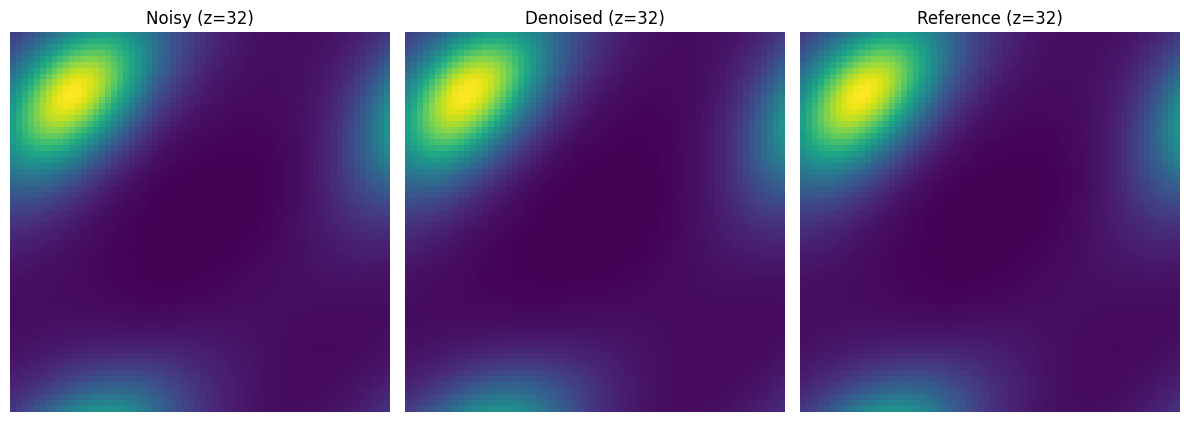


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_5283219951_scunet_pre_denoised.npy
Sample 5283219951 | scunet_pre JSD = 0.000037

=== Running model: scunet_ft ===

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0002
JSD   (noisy vs ref):     0.000002
JSD   (denoised vs ref):  0.000026

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0002
JSD   (noisy vs ref):     0.000002
JSD   (denoised vs ref):  0.000026


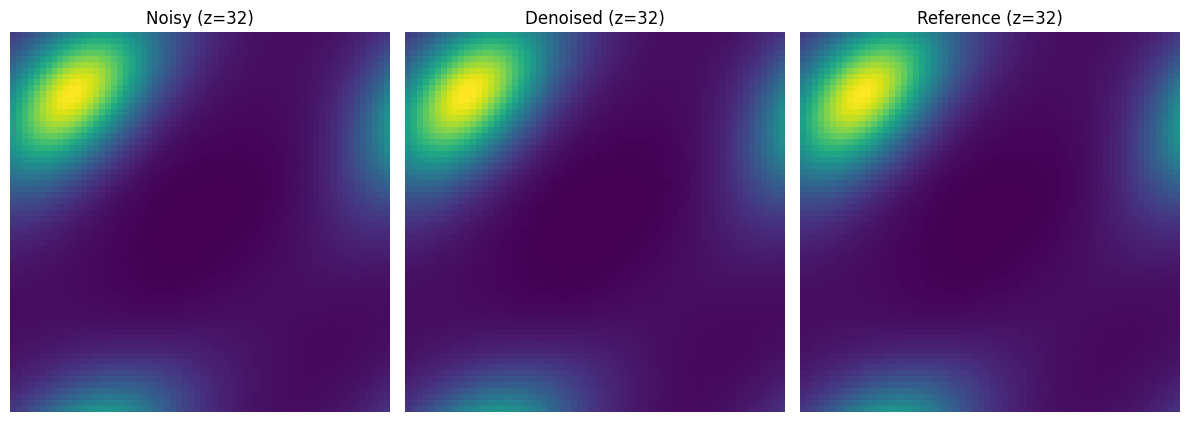


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_5283219951_scunet_ft_denoised.npy
Sample 5283219951 | scunet_ft JSD = 0.000026


In [16]:
import glob
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import torch
import h5py

# ================= CPU-loading patch =================
_original_torch_load = torch.load
def torch_load_cpu(*args, **kwargs):
    if 'map_location' not in kwargs:
        kwargs['map_location'] = torch.device('cpu')
    return _original_torch_load(*args, **kwargs)
torch.load = torch_load_cpu

# ================= Paths & Models =================
base_dir = "/pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2"
ref_path = os.path.join(base_dir, "density_tot_ref_mean.h5")
noisy_files = [ '/pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_5283219951.h5']

models = [
    'scunet_trained',
    'scunet_pre',
    'scunet_ft',
]

print(f"Found {len(noisy_files)} noisy files.")

# ================= Reference JSD =================
results_ref = []
for noisy_path in noisy_files:
    match = re.search(r"(\d+)\.h5$", noisy_path)
    if not match:
        continue
    sample_num = int(match.group(1))

    with h5py.File(ref_path, 'r') as file:
        ref_d = file['density'][:]
    with h5py.File(noisy_path, 'r') as file:
        test_d = file['density'][:]

    jsd = D_JS(ref_d, test_d)
    results_ref.append((sample_num, jsd))

results_array_ref = np.array(sorted(results_ref, key=lambda x: x[0]))

# ================= Run models =================
results_dict = {model: [] for model in models}

for model_name in models:
    print(f"\n=== Running model: {model_name} ===")

    for noisy_path in noisy_files:
        match = re.search(r"(\d+)\.h5$", noisy_path)
        if not match:
            continue
        sample_num = int(match.group(1))

        output_file = os.path.splitext(os.path.basename(noisy_path))[0] + f"_{model_name}_denoised.npy"
        output_path = os.path.join(base_dir, output_file)

        denoised_den, jsd = run_denoising_pipeline(
            noisy_path,
            ref_path,
            model_name,
            output_file=output_path
        )

        results_dict[model_name].append((sample_num, jsd))
        print(f"Sample {sample_num} | {model_name} JSD = {jsd:.6f}")
